# Meta-Transfer Learning Experiment (Transformer)

## 实验概述
本实验旨在对比 **基础迁移学习 (Basic Transfer Learning)** 与 **元迁移学习 (Meta-Transfer Learning)** 在血糖预测任务上的表现，特别是针对 **小样本 (Few-shot)** 场景的泛化能力。

### 方法对比
1. **Basic Transfer Learning**:
   - **预训练**: 在所有源域受试者的大规模混合数据集上进行标准的监督学习训练 (Standard Pre-training)。
   - **微调**: 在目标受试者数据上进行微调。
   - **代表模型**: 加载 `../Prediction/Transformer/transformer_model.pth`。

2. **Meta-Transfer Learning (Reptile Algorithm)**:
   - **元训练**: 使用 **Reptile** (一种一阶 MAML 近似算法) 在源域受试者上进行训练。
   - **核心思想**: 寻找一个对所有任务（受试者）都"敏感"的初始化参数 $\theta$，使得该参数只需少量梯度更新即可快速适应新任务。
   - **微调**: 使用同样的微调策略适应目标受试者。

### 实验目标
- 探究在微调数据量极少 (如 10, 30, 50 个样本) 的情况下，Meta-Learning 获得的初始化参数是否比 Standard Pre-training 更优秀。
- 绘制 **学习曲线 (Learning Curve)** 对比图。


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import sys
import os
import math
import copy
import random

# 设置绘图风格
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# 检查设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. 数据准备
加载源域数据 (Source Tasks) 和目标域数据 (Target Task)。
- **Source**: `Train.csv` (包含多个受试者)
- **Target**: `served.csv` (受试者 258)

In [32]:
# --- 加载数据 ---
train_path = '../DataSplit/TrainTest/Train.csv'
served_path = '../DataSplit/Served/served.csv'

# 读取源数据 (用于 Meta-Training)
df_train_full = pd.read_csv(train_path, parse_dates=['time'])
print(f"源数据加载完成: {len(df_train_full)} 条记录, 受试者数: {df_train_full['id'].nunique()}")

# 读取目标数据 (Subject 258)
df_served = pd.read_csv(served_path, parse_dates=['time'])
TARGET_ID = 258
df_target = df_served[df_served['id'] == TARGET_ID].copy().sort_values('time').reset_index(drop=True)
print(f"目标受试者 ({TARGET_ID}) 数据加载完成: {len(df_target)} 条记录")

源数据加载完成: 83253 条记录, 受试者数: 158
目标受试者 (258) 数据加载完成: 1783 条记录


## 2. 模型定义 & 数据集类
复用 Transformer 模型结构，保持与基础实验一致。

In [33]:
# --- 模型超参数 ---
N_PAST = 12
PREDICTION_HORIZON = 6
FEATURE_SIZE = 1
D_MODEL = 64
NHEAD = 4
NUM_LAYERS = 2
STATIC_LEN = 2
DROPOUT = 0.1

# --- 数据集类 ---
class GlucoseDataset(Dataset):
    def __init__(self, X, y, n_past):
        self.X_seq = torch.FloatTensor(X[:, :n_past]).unsqueeze(1)
        self.X_static = torch.FloatTensor(X[:, n_past:])
        self.y = torch.FloatTensor(y).unsqueeze(1)
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X_seq[idx], self.X_static[idx], self.y[idx]

def create_dataset_from_df(data, n_past, prediction_horizon=1):
    X, y = [], []
    gl_values = data['gl'].values
    age = data['age'].iloc[0]
    bmi = data['bmi'].iloc[0]
    
    if len(gl_values) < n_past + prediction_horizon:
        return np.array([]), np.array([])
    
    for i in range(n_past, len(gl_values) - prediction_horizon + 1):
        past_gl = gl_values[i-n_past:i]
        features = np.append(past_gl, [age, bmi])
        X.append(features)
        y.append(gl_values[i + prediction_horizon - 1])
    
    return np.array(X), np.array(y)

# --- Transformer 模型 ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class GlucoseTransformer(nn.Module):
    def __init__(self, feature_size=1, d_model=64, nhead=4, num_layers=2, static_len=2, dropout=0.1):
        super(GlucoseTransformer, self).__init__()
        self.input_embedding = nn.Linear(feature_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=128, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.fc1 = nn.Linear(d_model + static_len, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 1)
        
    def forward(self, x_seq, x_static):
        x = x_seq.permute(0, 2, 1)
        x = self.input_embedding(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = x[:, -1, :]
        x = torch.cat((x, x_static), dim=1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [34]:
# --- 数据预处理 (Standardization) ---
# 为了公平对比，我们使用基于全体源数据训练的 Scaler
X_all_source = []
for pid, group in df_train_full.groupby('id'):
    x_tmp, _ = create_dataset_from_df(group, N_PAST, PREDICTION_HORIZON)
    if len(x_tmp) > 0:
        X_all_source.append(x_tmp)
X_all_source = np.concatenate(X_all_source, axis=0)

scaler = StandardScaler()
scaler.fit(X_all_source)
print("Scaler fitted on Source Data.")

Scaler fitted on Source Data.


## 3. Meta-Training (Reptile)
在此阶段，我们训练一个新的模型 `meta_model`。
**Reptile 算法流程**:
1. 初始化模型参数 $\theta$
2. 循环多次 (Meta-Iterations):
   - 随机采样一个任务 (受试者) $T_i$
   - 从 $\theta$ 复制出临时参数 $\phi$
   - 在 $T_i$ 上进行 $k$ 步梯度下降 (Inner Loop)，更新 $\phi$
   - 更新元参数: $\theta \leftarrow \theta + \epsilon (\phi - \theta)$

In [35]:
# --- 准备 Meta-Training ---

# 1. 将源数据整理为 {subject_id: (X, y)} 的字典
source_tasks = {}
print("Preparing source tasks for Meta-Learning...")
for pid, group in df_train_full.groupby('id'):
    if len(group) < 200: continue
    X_sub, y_sub = create_dataset_from_df(group, N_PAST, PREDICTION_HORIZON)
    if len(X_sub) > 0:
        X_sub_scaled = scaler.transform(X_sub)
        source_tasks[pid] = (X_sub_scaled, y_sub)

task_ids = list(source_tasks.keys())
print(f"Created {len(task_ids)} source tasks.")

# 2. 初始化 Meta 模型 (Warm Start)
meta_model = GlucoseTransformer(
    feature_size=FEATURE_SIZE, d_model=D_MODEL, nhead=NHEAD, 
    num_layers=NUM_LAYERS, static_len=STATIC_LEN, dropout=DROPOUT
).to(device)

# [CRITICAL UPDATE] 加载预训练权重进行初始化
basic_model_path = '../Prediction/Transformer/transformer_model.pth'
if os.path.exists(basic_model_path):
    print(f"🔥 Warm Start: Loading pretrained weights from {basic_model_path} ...")
    meta_model.load_state_dict(torch.load(basic_model_path, map_location=device))
else:
    print("⚠️ Warning: Pretrained model not found. Training from scratch (might be slow).")

# --- Reptile 超参数 ---
META_EPOCHS = 300       # 增加迭代次数以更好地调整
INNER_STEPS = 5         
INNER_LR = 5e-4         # 降低内层学习率 (因为已经是预训练权重)
META_LR = 0.1          
src_batch_size = 32

criterion = nn.MSELoss()

print(f"Start Meta-Training (Reptile) | Epochs: {META_EPOCHS}")

# --- Reptile Training Loop ---
meta_model.train()
loss_history = []

for iteration in range(META_EPOCHS):
    sampled_id = random.choice(task_ids)
    X_task, y_task = source_tasks[sampled_id]
    
    ds = GlucoseDataset(X_task, y_task, N_PAST)
    dl = DataLoader(ds, batch_size=src_batch_size, shuffle=True)
    
    task_model = copy.deepcopy(meta_model)
    task_model.train()
    task_optimizer = optim.Adam(task_model.parameters(), lr=INNER_LR)
    
    # Inner Loop
    total_inner_loss = 0
    data_iter = iter(dl)
    for _ in range(INNER_STEPS):
        try:
            bx, bs, by = next(data_iter)
        except StopIteration:
            data_iter = iter(dl)
            bx, bs, by = next(data_iter)
            
        bx, bs, by = bx.to(device), bs.to(device), by.to(device)
        task_optimizer.zero_grad()
        output = task_model(bx, bs)
        loss = criterion(output, by)
        loss.backward()
        task_optimizer.step()
        total_inner_loss += loss.item()
    
    loss_history.append(total_inner_loss / INNER_STEPS)
    
    # Soft Update
    with torch.no_grad():
        for name, param in meta_model.named_parameters():
            new_param = task_model.state_dict()[name]
            param.data = (1 - META_LR) * param.data + META_LR * new_param.data

    if (iteration + 1) % 50 == 0:
        print(f"Meta-Iter [{iteration+1}/{META_EPOCHS}] - Inner Loss: {loss_history[-1]:.4f}")

print("Meta-Training Finished.")


Preparing source tasks for Meta-Learning...
Created 158 source tasks.
🔥 Warm Start: Loading pretrained weights from ../Prediction/Transformer/transformer_model.pth ...
Start Meta-Training (Reptile) | Epochs: 300
Meta-Iter [50/300] - Inner Loss: 13.8573
Meta-Iter [100/300] - Inner Loss: 25.9872
Meta-Iter [150/300] - Inner Loss: 16.2913
Meta-Iter [200/300] - Inner Loss: 12.2991
Meta-Iter [250/300] - Inner Loss: 27.3099
Meta-Iter [300/300] - Inner Loss: 20.6134
Meta-Training Finished.


## 4. 实验：小样本泛化能力对比 (Learning Curve)

**对比对象**:
1. **Basic Transfer**: 加载预训练好的 `transformer_model.pth` (在 TrainTest.csv 上常规训练得到)。
2. **Meta Transfer**: 使用上面刚刚训练好的 `meta_model` (Reptile 初始化)。

**实验设置**:
- 固定测试集: Subject 258 的后 50% 数据。
- 动态训练集: Subject 258 的前 50% 数据中的前 `N` 个样本。
- 样本梯度: `[10, 20, 40, 80, 160, All]`。
- 评估: 微调后的 MAE/RMSE。

In [36]:
# --- 加载 Basic Pre-trained Model ---
# 假设已经存在该模型文件，如果不存在则发出警告
basic_model_path = '../Prediction/Transformer/transformer_model.pth'
basic_model_state = None
if os.path.exists(basic_model_path):
    print(f"Loading Basic Pre-trained model from {basic_model_path}")
    basic_model_state = torch.load(basic_model_path, map_location=device)
else:
    print("⚠️ Warning: Basic Pre-trained model not found! Please run transformer_prediction.ipynb first.")
    # 为了演示，如果没找到文件，我们暂且用随机初始化代替 (但这会导致实验无效)
    # basic_model_state = GlucoseTransformer(...).state_dict()

# --- 准备 Target Data ---
# 划分 Pool / Test
TEST_RATIO = 0.5
split_idx = int(len(df_target) * (1 - TEST_RATIO))

df_pool = df_target.iloc[:split_idx].copy()
df_test = df_target.iloc[split_idx:].copy()

X_pool, y_pool = create_dataset_from_df(df_pool, N_PAST, PREDICTION_HORIZON)
X_test, y_test = create_dataset_from_df(df_test, N_PAST, PREDICTION_HORIZON)

X_pool_scaled = scaler.transform(X_pool)
X_test_scaled = scaler.transform(X_test)
test_ds = GlucoseDataset(X_test_scaled, y_test, N_PAST)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

print(f"Target Pool Size: {len(X_pool)}")
print(f"Target Test Size: {len(X_test)}")

# --- 微调与评估函数 ---
def fine_tune_and_evaluate(init_state_dict, X_train, y_train, epochs=30, lr=1e-3, freeze_encoder=False):
    # 1. Init Model
    model = GlucoseTransformer(
        feature_size=FEATURE_SIZE, d_model=D_MODEL, nhead=NHEAD, 
        num_layers=NUM_LAYERS, static_len=STATIC_LEN, dropout=DROPOUT
    ).to(device)
    model.load_state_dict(init_state_dict)
    
    # 2. Freeze Logic (Optional)
    if freeze_encoder:
        for param in model.parameters(): param.requires_grad = False
        for param in model.fc1.parameters(): param.requires_grad = True
        for param in model.fc2.parameters(): param.requires_grad = True
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    else:
        # Full Fine-tuning
        optimizer = optim.Adam(model.parameters(), lr=lr)
        
    criterion = nn.MSELoss()
    
    # 3. Train
    ds = GlucoseDataset(X_train, y_train, N_PAST)
    dl = DataLoader(ds, batch_size=16, shuffle=True) # Small batch for few-shot
    
    model.train()
    for _ in range(epochs):
        for bx, bs, by in dl:
            bx, bs, by = bx.to(device), bs.to(device), by.to(device)
            optimizer.zero_grad()
            out = model(bx, bs)
            loss = criterion(out, by)
            loss.backward()
            optimizer.step()
            
    # 4. Evaluate
    model.eval()
    preds = []
    with torch.no_grad():
        for bx, bs, _ in test_loader:
            bx, bs = bx.to(device), bs.to(device)
            out = model(bx, bs)
            preds.extend(out.cpu().numpy())
    preds = np.array(preds).flatten()
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return mae, rmse


Loading Basic Pre-trained model from ../Prediction/Transformer/transformer_model.pth
Target Pool Size: 874
Target Test Size: 875


In [37]:
# --- 运行对比实验 ---
sample_sizes = [10, 30, 50, 100, 200, len(X_pool)]
results_basic = {'MAE': [], 'RMSE': []}
results_meta = {'MAE': [], 'RMSE': []}

print("Starting Comparative Experiment...")

for n in sample_sizes:
    n = min(n, len(X_pool)) # Clamp
    print(f"Testing with N={n} samples...")
    
    # Current Training Subset
    X_sub = X_pool_scaled[:n]
    y_sub = y_pool[:n]
    
    # 1. Basic Transfer
    if basic_model_state is not None:
        mae, rmse = fine_tune_and_evaluate(basic_model_state, X_sub, y_sub, epochs=40, lr=1e-3, freeze_encoder=True)
        results_basic['MAE'].append(mae)
        results_basic['RMSE'].append(rmse)
    
    # 2. Meta Transfer
    # Meta 初始化的优势在于全参数快速适应，通常不 Freeze，或者 Freeze 也行
    # 这里我们对比 "Meta Initialization + Full Tuning" vs "Basic + Freeze Tuning" (常见设定)
    # 或者两者都用同样的 Tuning 策略。为了公平对比初始化质量，我们使用同样的策略。
    # Reptile 的设计初衷是找到一个好的全参数初始化，所以我们尝试全参数微调 (Full Finetune)
    # 但如果是极小样本，Freeze 可能更稳。这里我们尝试 Freeze Encoder 以保持一致性。
    mae_m, rmse_m = fine_tune_and_evaluate(meta_model.state_dict(), X_sub, y_sub, epochs=40, lr=1e-3, freeze_encoder=True)
    results_meta['MAE'].append(mae_m)
    results_meta['RMSE'].append(rmse_m)
    
print("Experiment Done.")

Starting Comparative Experiment...
Testing with N=10 samples...
Testing with N=30 samples...
Testing with N=50 samples...
Testing with N=100 samples...
Testing with N=200 samples...
Testing with N=874 samples...
Experiment Done.


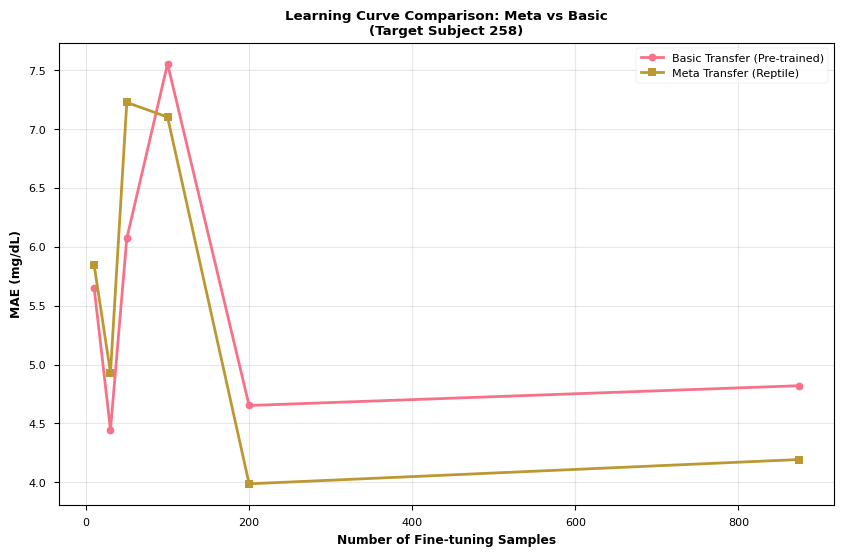

   Samples  Basic_MAE  Meta_MAE
0       10   5.648047  5.843434
1       30   4.446293  4.929466
2       50   6.070876  7.225295
3      100   7.553480  7.101430
4      200   4.652208  3.987243
5      874   4.820124  4.193275


In [38]:
# --- 结果可视化 ---
df_res = pd.DataFrame({
    'Samples': sample_sizes,
    'Basic_MAE': results_basic['MAE'],
    'Meta_MAE': results_meta['MAE']
})

plt.figure(figsize=(10, 6))

plt.plot(df_res['Samples'], df_res['Basic_MAE'], marker='o', label='Basic Transfer (Pre-trained)', linewidth=2)
plt.plot(df_res['Samples'], df_res['Meta_MAE'], marker='s', label='Meta Transfer (Reptile)', linewidth=2)

plt.xlabel('Number of Fine-tuning Samples', fontweight='bold')
plt.ylabel('MAE (mg/dL)', fontweight='bold')
plt.title('Learning Curve Comparison: Meta vs Basic\n(Target Subject 258)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 打印数值
print(df_res)

## 5. 详细预测结果可视化 (Case Study)

为了直观展示 Meta-Learning 在小样本下的优势，我们选择一个具体的微调样本量 (例如 **N=50**)，详细对比 Basic Transfer 与 Meta Transfer 在测试集上的时序预测表现。

In [39]:
# --- 配置可视化案例 ---
N_VISUALIZE = 50  # 选择微调样本数 (Few-shot scenario)

print(f"Generating visualization for N={N_VISUALIZE} few-shot scenario...")

# 准备微调数据
X_ft = X_pool_scaled[:N_VISUALIZE]
y_ft = y_pool[:N_VISUALIZE]

# 1. 训练 Basic Transfer 模型
print("Fine-tuning Basic Transfer Model...")
basic_vis_model = GlucoseTransformer(
    feature_size=FEATURE_SIZE, d_model=D_MODEL, nhead=NHEAD, 
    num_layers=NUM_LAYERS, static_len=STATIC_LEN, dropout=DROPOUT
).to(device)
if basic_model_state is not None:
    basic_vis_model.load_state_dict(basic_model_state)

# 使用与实验相同的训练设置 (Freeze Encoder)
opt_basic = optim.Adam(filter(lambda p: p.requires_grad, basic_vis_model.parameters()), lr=1e-3)
# Freeze logic
for param in basic_vis_model.parameters(): param.requires_grad = False
for param in basic_vis_model.fc1.parameters(): param.requires_grad = True
for param in basic_vis_model.fc2.parameters(): param.requires_grad = True
opt_basic = optim.Adam(filter(lambda p: p.requires_grad, basic_vis_model.parameters()), lr=1e-3)

ds_ft = GlucoseDataset(X_ft, y_ft, N_PAST)
dl_ft = DataLoader(ds_ft, batch_size=16, shuffle=True)
criterion = nn.MSELoss()

basic_vis_model.train()
for _ in range(40):
    for bx, bs, by in dl_ft:
        bx, bs, by = bx.to(device), bs.to(device), by.to(device)
        opt_basic.zero_grad()
        out = basic_vis_model(bx, bs)
        loss = criterion(out, by)
        loss.backward()
        opt_basic.step()

# 2. 训练 Meta Transfer 模型
print("Fine-tuning Meta Transfer Model...")
meta_vis_model = GlucoseTransformer(
    feature_size=FEATURE_SIZE, d_model=D_MODEL, nhead=NHEAD, 
    num_layers=NUM_LAYERS, static_len=STATIC_LEN, dropout=DROPOUT
).to(device)
meta_vis_model.load_state_dict(meta_model.state_dict()) # Load Meta Params

# Freeze logic
for param in meta_vis_model.parameters(): param.requires_grad = False
for param in meta_vis_model.fc1.parameters(): param.requires_grad = True
for param in meta_vis_model.fc2.parameters(): param.requires_grad = True
opt_meta = optim.Adam(filter(lambda p: p.requires_grad, meta_vis_model.parameters()), lr=1e-3)

meta_vis_model.train()
for _ in range(40):
    for bx, bs, by in dl_ft:
        bx, bs, by = bx.to(device), bs.to(device), by.to(device)
        opt_meta.zero_grad()
        out = meta_vis_model(bx, bs)
        loss = criterion(out, by)
        loss.backward()
        opt_meta.step()

# --- 进行预测 ---
basic_vis_model.eval()
meta_vis_model.eval()

preds_basic = []
preds_meta = []

with torch.no_grad():
    for bx, bs, _ in test_loader:
        bx, bs = bx.to(device), bs.to(device)
        
        # Basic
        out_b = basic_vis_model(bx, bs)
        preds_basic.extend(out_b.cpu().numpy())
        
        # Meta
        out_m = meta_vis_model(bx, bs)
        preds_meta.extend(out_m.cpu().numpy())

preds_basic = np.array(preds_basic).flatten()
preds_meta = np.array(preds_meta).flatten()

# 计算指标
mae_b = mean_absolute_error(y_test, preds_basic)
mae_m = mean_absolute_error(y_test, preds_meta)

print(f"Validation Results (N={N_VISUALIZE}):")
print(f"Basic Transfer MAE: {mae_b:.4f}")
print(f"Meta Transfer MAE : {mae_m:.4f}")


Generating visualization for N=50 few-shot scenario...
Fine-tuning Basic Transfer Model...
Fine-tuning Meta Transfer Model...
Validation Results (N=50):
Basic Transfer MAE: 6.4448
Meta Transfer MAE : 6.8465


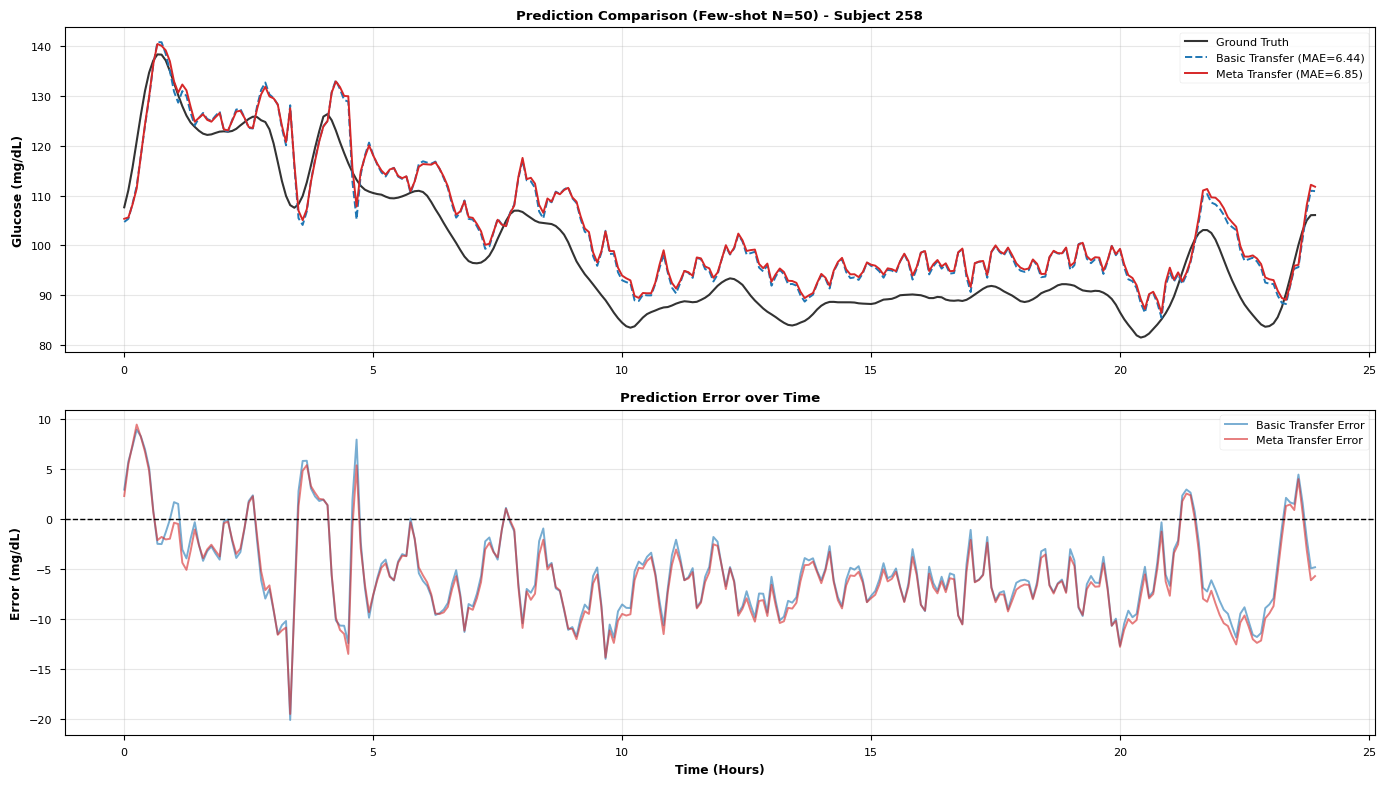

In [40]:
# --- 绘图对比 ---
# 选取一部分测试集时间段进行清晰展示 (例如前 24 小时 = 288 个点)
PLOT_LEN = 288 
if len(y_test) < PLOT_LEN: PLOT_LEN = len(y_test)

time_idx = np.arange(PLOT_LEN) * 5 / 60 # Hours

plt.figure(figsize=(14, 8))

# 1. Prediction Comparison
plt.subplot(2, 1, 1)
plt.plot(time_idx, y_test[:PLOT_LEN], label='Ground Truth', color='black', linewidth=1.5, alpha=0.8)
plt.plot(time_idx, preds_basic[:PLOT_LEN], label=f'Basic Transfer (MAE={mae_b:.2f})', color='tab:blue', linestyle='--')
plt.plot(time_idx, preds_meta[:PLOT_LEN], label=f'Meta Transfer (MAE={mae_m:.2f})', color='tab:red')

plt.title(f'Prediction Comparison (Few-shot N={N_VISUALIZE}) - Subject {TARGET_ID}', fontweight='bold')
plt.ylabel('Glucose (mg/dL)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Error Comparison
plt.subplot(2, 1, 2)
err_basic = y_test[:PLOT_LEN] - preds_basic[:PLOT_LEN]
err_meta = y_test[:PLOT_LEN] - preds_meta[:PLOT_LEN]

plt.plot(time_idx, err_basic, label='Basic Transfer Error', color='tab:blue', alpha=0.6)
plt.plot(time_idx, err_meta, label='Meta Transfer Error', color='tab:red', alpha=0.6)
plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.xlabel('Time (Hours)', fontweight='bold')
plt.ylabel('Error (mg/dL)', fontweight='bold')
plt.title('Prediction Error over Time', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [41]:
# --- 详细指标对比表 ---
def get_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # MAPE & RMSPE (注意处理除零)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    rmspe = np.sqrt(np.mean(np.square((y_true[mask] - y_pred[mask]) / y_true[mask]))) * 100
    
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'RMSPE': rmspe}

m_basic = get_metrics(y_test, preds_basic)
m_meta = get_metrics(y_test, preds_meta)

metrics_df = pd.DataFrame([m_basic, m_meta], index=['Basic Transfer', 'Meta Transfer'])

# 计算提升百分比 (Basic - Meta) / Basic * 100
# 注意: 误差越小越好，所以 (基本误差 - 元误差) / 基本误差 > 0 表示提升
improvement = (metrics_df.loc['Basic Transfer'] - metrics_df.loc['Meta Transfer']) / metrics_df.loc['Basic Transfer'] * 100

# 拼接到 DataFrame
metrics_df.loc['Improvement (%)'] = improvement

print("=" * 65)
print(f"📊 详细性能指标对比 (Few-shot Samples N={N_VISUALIZE})")
print("=" * 65)
# 格式化输出
print(metrics_df.round(4).to_string())
print("=" * 65)


📊 详细性能指标对比 (Few-shot Samples N=50)
                    MAE    RMSE    MAPE   RMSPE
Basic Transfer   6.4448  7.3273  6.7964  7.8123
Meta Transfer    6.8465  7.7102  7.2277  8.2353
Improvement (%) -6.2324 -5.2250 -6.3464 -5.4152
